In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import StandardScaler

import seaborn as sns

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [12]:
import warnings
warnings.filterwarnings('ignore')

In [13]:
songs_cohort_df = pd.read_csv('data/rolling_stones_spotify.csv')
songs_cohort_df.head()

,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


In [14]:
songs_cohort_df = songs_cohort_df.drop(['Unnamed: 0'],axis=1)
songs_cohort_df

,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.9320,-12.913,0.1100,118.001,0.0302,33,48640
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.9610,-4.803,0.0759,131.455,0.3180,34,253173
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.9560,-4.936,0.1150,130.066,0.3130,34,263160
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.8950,-5.535,0.1930,132.994,0.1470,32,305880
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.9660,-5.098,0.0930,130.533,0.2060,32,305106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,Carol,The Rolling Stones,1964-04-16,8,08l7M5UpRnffGl0FyuRiQZ,spotify:track:08l7M5UpRnffGl0FyuRiQZ,0.1570,0.466,0.932,0.006170,0.3240,-9.214,0.0429,177.340,0.9670,39,154080
1606,Tell Me,The Rolling Stones,1964-04-16,9,3JZllQBsTM6WwoJdzFDLhx,spotify:track:3JZllQBsTM6WwoJdzFDLhx,0.0576,0.509,0.706,0.000002,0.5160,-9.427,0.0843,122.015,0.4460,36,245266
1607,Can I Get A Witness,The Rolling Stones,1964-04-16,10,0t2qvfSBQ3Y08lzRRoVTdb,spotify:track:0t2qvfSBQ3Y08lzRRoVTdb,0.3710,0.790,0.774,0.000000,0.0669,-7.961,0.0720,97.035,0.8350,30,176080
1608,You Can Make It If You Try,The Rolling Stones,1964-04-16,11,5ivIs5vwSj0RChOIvlY3On,spotify:track:5ivIs5vwSj0RChOIvlY3On,0.2170,0.700,0.546,0.000070,0.1660,-9.567,0.0622,102.634,0.5320,27,121680


In [15]:
songs_cohort_df.shape

(1610, 17)

In [16]:
songs_cohort_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1610 non-null   str    
 1   album             1610 non-null   str    
 2   release_date      1610 non-null   str    
 3   track_number      1610 non-null   int64  
 4   id                1610 non-null   str    
 5   uri               1610 non-null   str    
 6   acousticness      1610 non-null   float64
 7   danceability      1610 non-null   float64
 8   energy            1610 non-null   float64
 9   instrumentalness  1610 non-null   float64
 10  liveness          1610 non-null   float64
 11  loudness          1610 non-null   float64
 12  speechiness       1610 non-null   float64
 13  tempo             1610 non-null   float64
 14  valence           1610 non-null   float64
 15  popularity        1610 non-null   int64  
 16  duration_ms       1610 non-null   int64  
dtypes: flo

In [17]:
songs_cohort_df.describe()

,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6.971615,0.069512,126.082033,0.582165,20.788199,257736.488199
std,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,2.994003,0.051631,29.233483,0.231253,12.426859,108333.474920
min,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24.408000,0.023200,46.525000,0.000000,0.000000,21000.000000
25%,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8.982500,0.036500,107.390750,0.404250,13.000000,190613.000000
50%,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6.523000,0.051200,124.404500,0.583000,20.000000,243093.000000
75%,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4.608750,0.086600,142.355750,0.778000,27.000000,295319.750000
max,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-1.014000,0.624000,216.304000,0.974000,80.000000,981866.000000


### 1. Initial data inspection and data cleaning:

#### a. Examine the data initially to identify duplicates, missing values, irrelevant entries, or outliers. Check for any instances of erroneous entries and rectify them as needed

In [18]:
songs_cohort_df.isnull().sum()

name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

In [19]:
songs_cohort_df.duplicated().sum()

np.int64(0)

In [20]:
songs_cohort_df = songs_cohort_df.drop_duplicates()
songs_cohort_df

,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.9320,-12.913,0.1100,118.001,0.0302,33,48640
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.9610,-4.803,0.0759,131.455,0.3180,34,253173
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.9560,-4.936,0.1150,130.066,0.3130,34,263160
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.8950,-5.535,0.1930,132.994,0.1470,32,305880
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.9660,-5.098,0.0930,130.533,0.2060,32,305106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,Carol,The Rolling Stones,1964-04-16,8,08l7M5UpRnffGl0FyuRiQZ,spotify:track:08l7M5UpRnffGl0FyuRiQZ,0.1570,0.466,0.932,0.006170,0.3240,-9.214,0.0429,177.340,0.9670,39,154080
1606,Tell Me,The Rolling Stones,1964-04-16,9,3JZllQBsTM6WwoJdzFDLhx,spotify:track:3JZllQBsTM6WwoJdzFDLhx,0.0576,0.509,0.706,0.000002,0.5160,-9.427,0.0843,122.015,0.4460,36,245266
1607,Can I Get A Witness,The Rolling Stones,1964-04-16,10,0t2qvfSBQ3Y08lzRRoVTdb,spotify:track:0t2qvfSBQ3Y08lzRRoVTdb,0.3710,0.790,0.774,0.000000,0.0669,-7.961,0.0720,97.035,0.8350,30,176080
1608,You Can Make It If You Try,The Rolling Stones,1964-04-16,11,5ivIs5vwSj0RChOIvlY3On,spotify:track:5ivIs5vwSj0RChOIvlY3On,0.2170,0.700,0.546,0.000070,0.1660,-9.567,0.0622,102.634,0.5320,27,121680


In [21]:
songs_cohort_df['release_date'] = pd.to_datetime(songs_cohort_df['release_date'])
songs_cohort_df['release_year'] = songs_cohort_df['release_date'].dt.year
songs_cohort_df

,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,release_year
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.9320,-12.913,0.1100,118.001,0.0302,33,48640,2022
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.9610,-4.803,0.0759,131.455,0.3180,34,253173,2022
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.9560,-4.936,0.1150,130.066,0.3130,34,263160,2022
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.8950,-5.535,0.1930,132.994,0.1470,32,305880,2022
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.9660,-5.098,0.0930,130.533,0.2060,32,305106,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,Carol,The Rolling Stones,1964-04-16,8,08l7M5UpRnffGl0FyuRiQZ,spotify:track:08l7M5UpRnffGl0FyuRiQZ,0.1570,0.466,0.932,0.006170,0.3240,-9.214,0.0429,177.340,0.9670,39,154080,1964
1606,Tell Me,The Rolling Stones,1964-04-16,9,3JZllQBsTM6WwoJdzFDLhx,spotify:track:3JZllQBsTM6WwoJdzFDLhx,0.0576,0.509,0.706,0.000002,0.5160,-9.427,0.0843,122.015,0.4460,36,245266,1964
1607,Can I Get A Witness,The Rolling Stones,1964-04-16,10,0t2qvfSBQ3Y08lzRRoVTdb,spotify:track:0t2qvfSBQ3Y08lzRRoVTdb,0.3710,0.790,0.774,0.000000,0.0669,-7.961,0.0720,97.035,0.8350,30,176080,1964
1608,You Can Make It If You Try,The Rolling Stones,1964-04-16,11,5ivIs5vwSj0RChOIvlY3On,spotify:track:5ivIs5vwSj0RChOIvlY3On,0.2170,0.700,0.546,0.000070,0.1660,-9.567,0.0622,102.634,0.5320,27,121680,1964


In [22]:
numeric_cols = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity', 'duration_ms']
scaler = StandardScaler()
songs_cohort_df[numeric_cols] = scaler.fit_transform(songs_cohort_df[numeric_cols])
songs_cohort_df

,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,release_year
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,-0.739355,-0.041343,1.115764,3.012099,1.261552,-1.985045,0.784410,-0.276517,-2.387590,0.982999,-1.930719,2022
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.820518,-1.007963,0.960062,0.249238,1.344648,0.724545,0.123753,0.183852,-1.142678,1.063495,-0.042138,2022
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.728140,-0.584626,0.982305,0.853953,1.330321,0.680109,0.881280,0.136323,-1.164306,1.063495,0.050079,2022
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,1.392383,-0.704571,1.071278,-0.594080,1.155532,0.479980,2.392459,0.236514,-1.882359,0.902504,0.444539,2022
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.657756,-1.170242,0.982305,-0.392050,1.358975,0.625984,0.455050,0.152303,-1.627147,0.902504,0.437392,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,Carol,The Rolling Stones,1964-04-16,8,08l7M5UpRnffGl0FyuRiQZ,spotify:track:08l7M5UpRnffGl0FyuRiQZ,-0.411192,-0.020176,0.776555,-0.572125,-0.480613,-0.749192,-0.515591,1.753944,1.664646,1.465975,-0.957125,1964
1606,Tell Me,The Rolling Stones,1964-04-16,9,3JZllQBsTM6WwoJdzFDLhx,spotify:track:3JZllQBsTM6WwoJdzFDLhx,-0.848449,0.283215,-0.480188,-0.594461,0.069544,-0.820356,0.286496,-0.139166,-0.588999,1.224487,-0.115148,1964
1607,Can I Get A Witness,The Rolling Stones,1964-04-16,10,0t2qvfSBQ3Y08lzRRoVTdb,spotify:track:0t2qvfSBQ3Y08lzRRoVTdb,0.530186,2.265844,-0.102053,-0.594467,-1.217308,-0.330558,0.048195,-0.993931,1.093665,0.741512,-0.753985,1964
1608,You Can Make It If You Try,The Rolling Stones,1964-04-16,11,5ivIs5vwSj0RChOIvlY3On,spotify:track:5ivIs5vwSj0RChOIvlY3On,-0.147254,1.630838,-1.369917,-0.594213,-0.933346,-0.867131,-0.141672,-0.802344,-0.216997,0.500024,-1.256295,1964


In [23]:
songs_cohort_df = songs_cohort_df[(np.abs(stats.zscore(songs_cohort_df[numeric_cols])) < 3).all(axis=1)]
songs_cohort_df

,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,release_year
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.820518,-1.007963,0.960062,0.249238,1.344648,0.724545,0.123753,0.183852,-1.142678,1.063495,-0.042138,2022
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.728140,-0.584626,0.982305,0.853953,1.330321,0.680109,0.881280,0.136323,-1.164306,1.063495,0.050079,2022
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,1.392383,-0.704571,1.071278,-0.594080,1.155532,0.479980,2.392459,0.236514,-1.882359,0.902504,0.444539,2022
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.657756,-1.170242,0.982305,-0.392050,1.358975,0.625984,0.455050,0.152303,-1.627147,0.902504,0.437392,2022
5,Monkey Man - Live,Licked Live In NYC,2022-06-10,6,3ixZ1NQk5sqvBZgWeIdiqr,spotify:track:3ixZ1NQk5sqvBZgWeIdiqr,0.107886,-0.909184,0.910014,-0.141836,0.714260,0.478644,0.425989,-0.836768,-1.977522,0.822008,-0.124132,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,Carol,The Rolling Stones,1964-04-16,8,08l7M5UpRnffGl0FyuRiQZ,spotify:track:08l7M5UpRnffGl0FyuRiQZ,-0.411192,-0.020176,0.776555,-0.572125,-0.480613,-0.749192,-0.515591,1.753944,1.664646,1.465975,-0.957125,1964
1606,Tell Me,The Rolling Stones,1964-04-16,9,3JZllQBsTM6WwoJdzFDLhx,spotify:track:3JZllQBsTM6WwoJdzFDLhx,-0.848449,0.283215,-0.480188,-0.594461,0.069544,-0.820356,0.286496,-0.139166,-0.588999,1.224487,-0.115148,1964
1607,Can I Get A Witness,The Rolling Stones,1964-04-16,10,0t2qvfSBQ3Y08lzRRoVTdb,spotify:track:0t2qvfSBQ3Y08lzRRoVTdb,0.530186,2.265844,-0.102053,-0.594467,-1.217308,-0.330558,0.048195,-0.993931,1.093665,0.741512,-0.753985,1964
1608,You Can Make It If You Try,The Rolling Stones,1964-04-16,11,5ivIs5vwSj0RChOIvlY3On,spotify:track:5ivIs5vwSj0RChOIvlY3On,-0.147254,1.630838,-1.369917,-0.594213,-0.933346,-0.867131,-0.141672,-0.802344,-0.216997,0.500024,-1.256295,1964


In [24]:
songs_cohort_df.shape

(1508, 18)

In [25]:
songs_cohort_df['album'] = songs_cohort_df['album'].str.title()
songs_cohort_df

,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,release_year
1,Street Fighting Man - Live,Licked Live In Nyc,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.820518,-1.007963,0.960062,0.249238,1.344648,0.724545,0.123753,0.183852,-1.142678,1.063495,-0.042138,2022
2,Start Me Up - Live,Licked Live In Nyc,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.728140,-0.584626,0.982305,0.853953,1.330321,0.680109,0.881280,0.136323,-1.164306,1.063495,0.050079,2022
3,If You Can't Rock Me - Live,Licked Live In Nyc,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,1.392383,-0.704571,1.071278,-0.594080,1.155532,0.479980,2.392459,0.236514,-1.882359,0.902504,0.444539,2022
4,Don’t Stop - Live,Licked Live In Nyc,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.657756,-1.170242,0.982305,-0.392050,1.358975,0.625984,0.455050,0.152303,-1.627147,0.902504,0.437392,2022
5,Monkey Man - Live,Licked Live In Nyc,2022-06-10,6,3ixZ1NQk5sqvBZgWeIdiqr,spotify:track:3ixZ1NQk5sqvBZgWeIdiqr,0.107886,-0.909184,0.910014,-0.141836,0.714260,0.478644,0.425989,-0.836768,-1.977522,0.822008,-0.124132,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,Carol,The Rolling Stones,1964-04-16,8,08l7M5UpRnffGl0FyuRiQZ,spotify:track:08l7M5UpRnffGl0FyuRiQZ,-0.411192,-0.020176,0.776555,-0.572125,-0.480613,-0.749192,-0.515591,1.753944,1.664646,1.465975,-0.957125,1964
1606,Tell Me,The Rolling Stones,1964-04-16,9,3JZllQBsTM6WwoJdzFDLhx,spotify:track:3JZllQBsTM6WwoJdzFDLhx,-0.848449,0.283215,-0.480188,-0.594461,0.069544,-0.820356,0.286496,-0.139166,-0.588999,1.224487,-0.115148,1964
1607,Can I Get A Witness,The Rolling Stones,1964-04-16,10,0t2qvfSBQ3Y08lzRRoVTdb,spotify:track:0t2qvfSBQ3Y08lzRRoVTdb,0.530186,2.265844,-0.102053,-0.594467,-1.217308,-0.330558,0.048195,-0.993931,1.093665,0.741512,-0.753985,1964
1608,You Can Make It If You Try,The Rolling Stones,1964-04-16,11,5ivIs5vwSj0RChOIvlY3On,spotify:track:5ivIs5vwSj0RChOIvlY3On,-0.147254,1.630838,-1.369917,-0.594213,-0.933346,-0.867131,-0.141672,-0.802344,-0.216997,0.500024,-1.256295,1964


In [26]:
songs_cohort_df.info()

<class 'pandas.DataFrame'>
Index: 1508 entries, 1 to 1609
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   name              1508 non-null   str           
 1   album             1508 non-null   str           
 2   release_date      1508 non-null   datetime64[us]
 3   track_number      1508 non-null   int64         
 4   id                1508 non-null   str           
 5   uri               1508 non-null   str           
 6   acousticness      1508 non-null   float64       
 7   danceability      1508 non-null   float64       
 8   energy            1508 non-null   float64       
 9   instrumentalness  1508 non-null   float64       
 10  liveness          1508 non-null   float64       
 11  loudness          1508 non-null   float64       
 12  speechiness       1508 non-null   float64       
 13  tempo             1508 non-null   float64       
 14  valence           1508 non-null   float6

### 3. Perform exploratory data analysis and feature engineering

#### a. Utilize suitable visualizations to identify the two albums that should be recommended to anyone based on the number of popular songs in each album

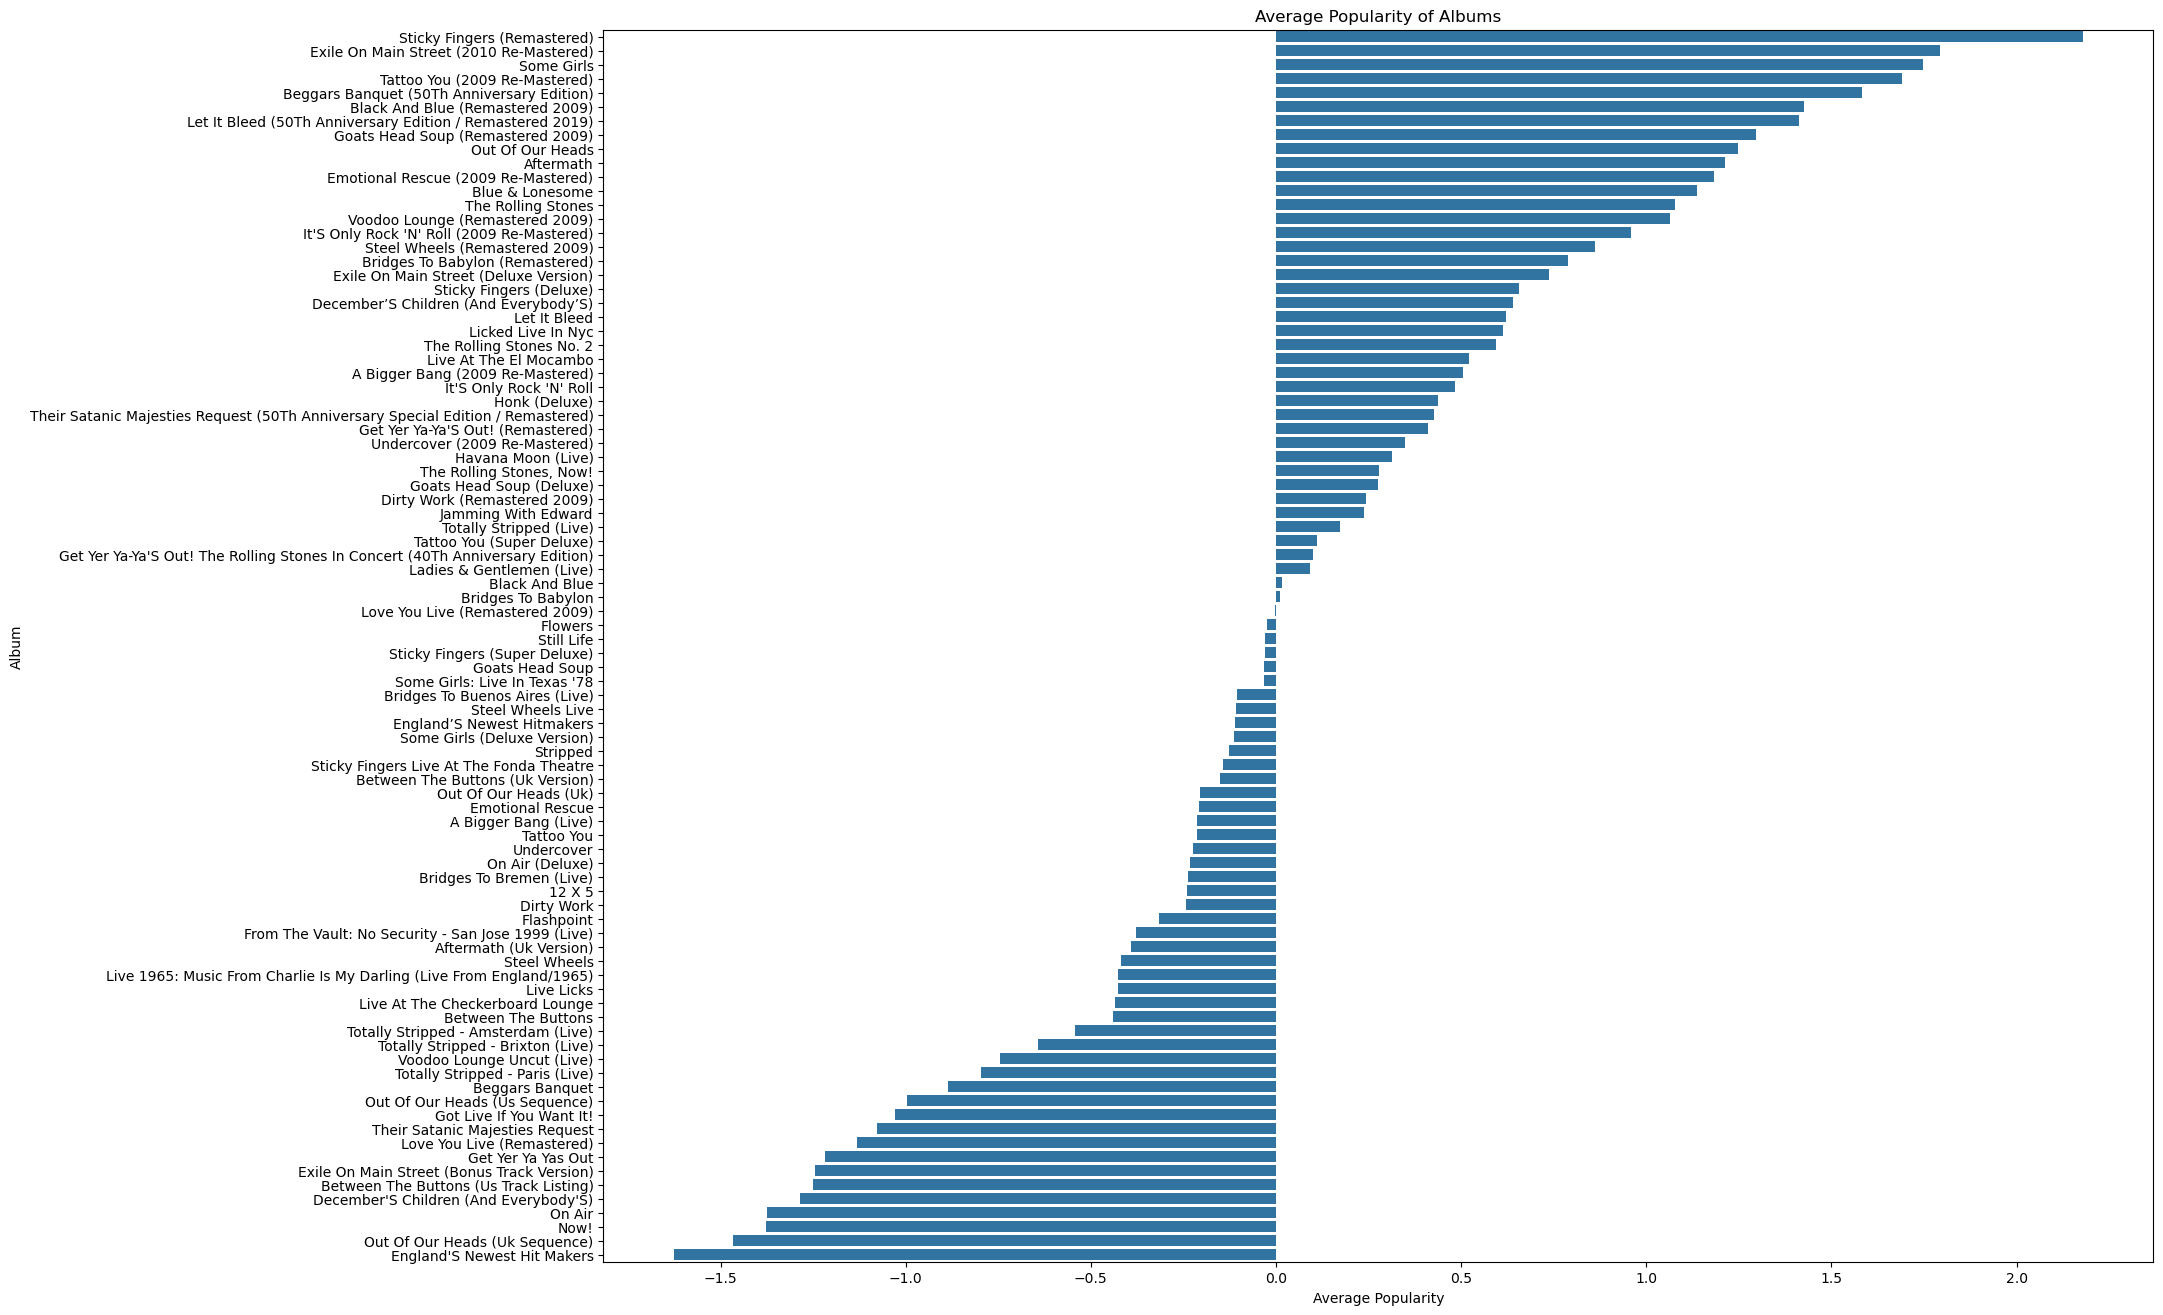

The top two albums recommended based on the number of popular songs are : 
album
Sticky Fingers (Remastered)                2.178938
Exile On Main Street (2010 Re-Mastered)    1.792693
Name: popularity, dtype: float64


In [27]:
album_popularity = songs_cohort_df.groupby('album')['popularity'].mean().sort_values(ascending=False)

plt.figure(figsize=(20,16))
sns.barplot(x=album_popularity.values, y=album_popularity.index)
plt.title('Average Popularity of Albums')
plt.xlabel('Average Popularity')
plt.ylabel('Album')
plt.show()

# Identify the two albums with the most popular songs
top_two_albums = album_popularity.head(2)
print(f"The top two albums recommended based on the number of popular songs are : \n{top_two_albums}")


#### b. Conduct exploratory data analysis to delve into various features of songs, aiming to identify patterns

<Figure size 1200x1000 with 0 Axes>

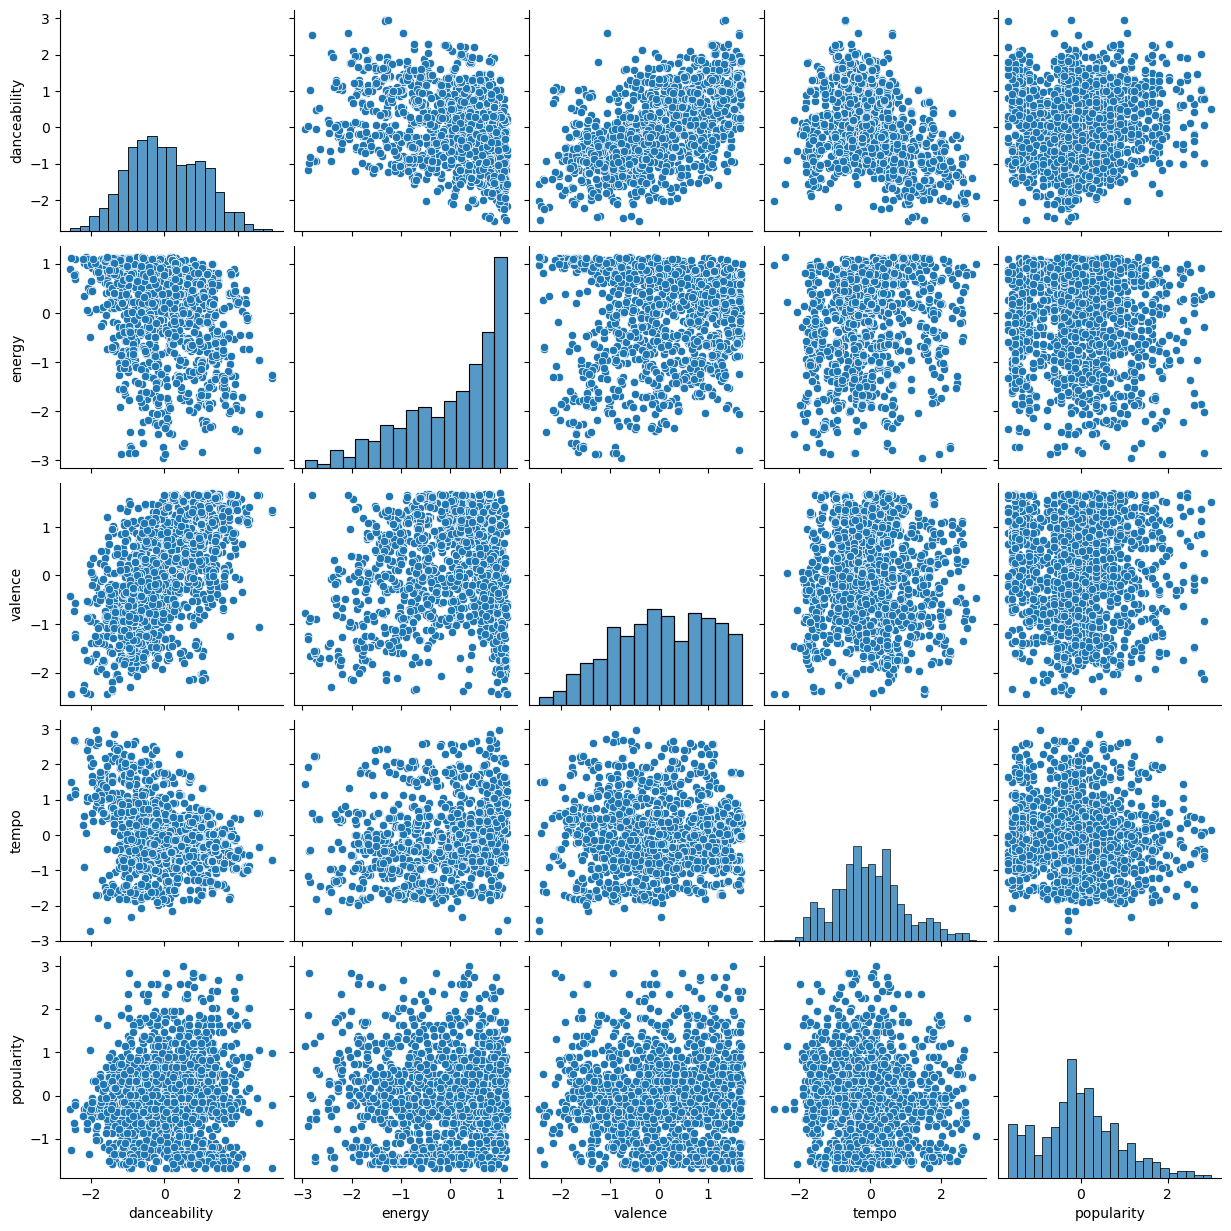

In [28]:
plt.figure(figsize=(12,10))
sns.pairplot(songs_cohort_df[['danceability','energy', 'valence', 'tempo', 'popularity']])

In [29]:
numeric_cols = [
    'acousticness', 'danceability', 'energy', 'instrumentalness', 
    'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 
    'popularity', 'duration_ms'
]


df_numeric = songs_cohort_df[numeric_cols].copy()

for col in df_numeric.columns:
    df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce')

df_numeric = df_numeric.dropna()

corr_matrix = df_numeric.corr()

print("\nCorrelation Matrix:")
corr_matrix


Correlation Matrix:


,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
acousticness,1.000000,0.081612,-0.363625,0.046211,-0.112355,-0.200142,-0.119025,-0.173219,-0.115866,0.105469,0.106276
danceability,0.081612,1.000000,-0.312081,-0.024561,-0.510922,-0.297296,-0.342865,-0.318273,0.535234,0.099812,-0.233560
energy,-0.363625,-0.312081,1.000000,0.122720,0.503274,0.694790,0.479397,0.215697,0.046665,-0.051860,0.156284
instrumentalness,0.046211,-0.024561,0.122720,1.000000,0.001311,0.050053,-0.015671,0.029341,0.127868,0.011834,-0.138705
liveness,-0.112355,-0.510922,0.503274,0.001311,1.000000,0.340895,0.429659,0.113494,-0.341884,-0.180020,0.313684
loudness,-0.200142,-0.297296,0.694790,0.050053,0.340895,1.000000,0.292776,0.112611,-0.088728,0.167845,0.236534
speechiness,-0.119025,-0.342865,0.479397,-0.015671,0.429659,0.292776,1.000000,0.247941,-0.385720,-0.135269,0.132173
tempo,-0.173219,-0.318273,0.215697,0.029341,0.113494,0.112611,0.247941,1.000000,0.009591,-0.063744,-0.038236
valence,-0.115866,0.535234,0.046665,0.127868,-0.341884,-0.088728,-0.385720,0.009591,1.000000,0.035501,-0.302516
popularity,0.105469,0.099812,-0.051860,0.011834,-0.180020,0.167845,-0.135269,-0.063744,0.035501,1.000000,0.116511


Text(0.5, 1.0, 'Correlation Matrix of Song Features')

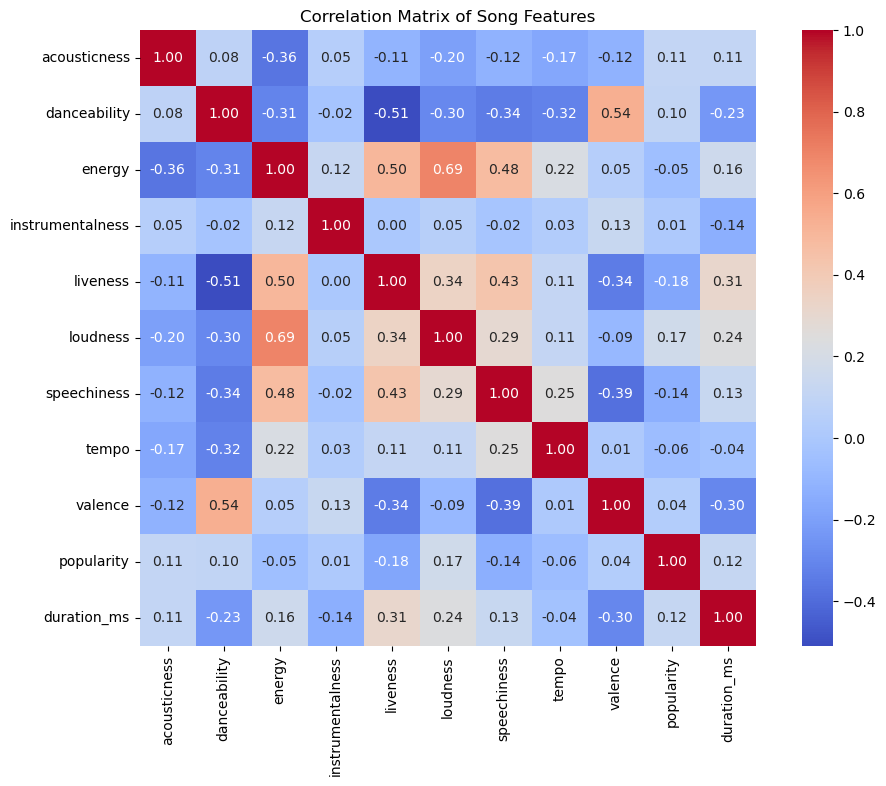

In [30]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Song Features')

#### c. Examine the relationship between a song's popularity and various factors, exploring how this correlation has evolved

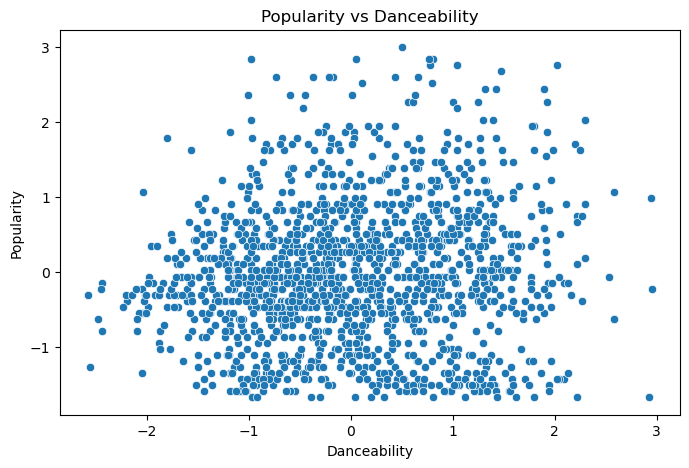

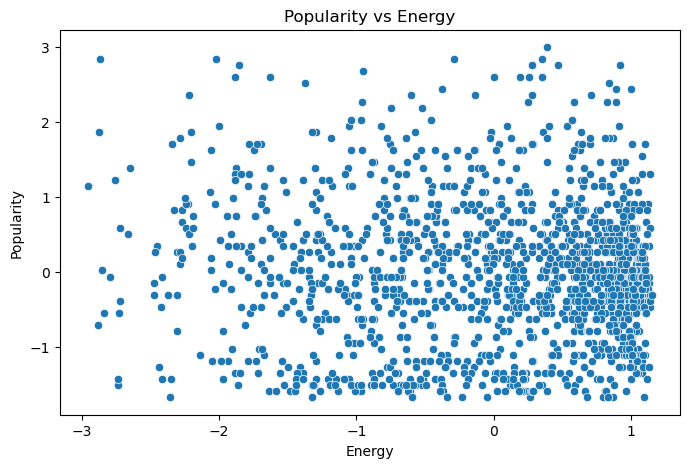

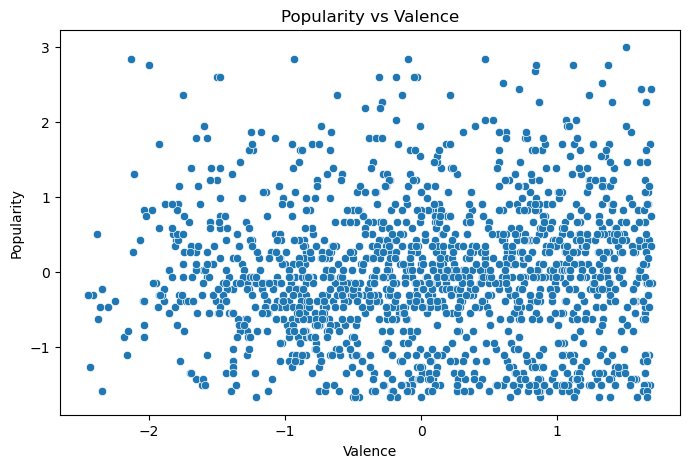

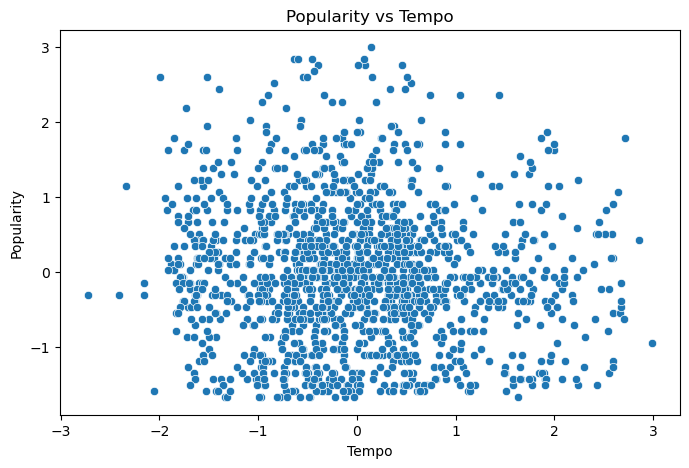

In [34]:
features = ['danceability', 'energy', 'valence', 'tempo']
for feature in features:
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=songs_cohort_df, x=feature, y='popularity')
    plt.title(f'Popularity vs {feature.capitalize()}')
    plt.xlabel(feature.capitalize())
    plt.ylabel('Popularity')

#### d. Provide insights on the significance of dimensionality reduction techniques. Share your ideas and elucidate your observations

Explained Variance: [0.33898434 0.21160023]


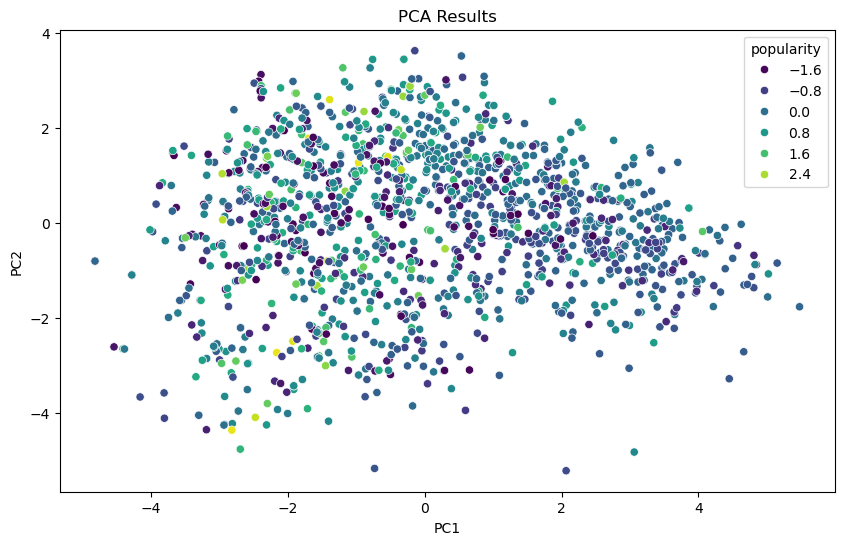

In [37]:
numeric_features = songs_cohort_df.select_dtypes(include=['float64', 'int64']).drop(columns=['popularity', 'duration_ms'])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(numeric_features)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

explained_variance = pca.explained_variance_ratio_
print(f'Explained Variance: {explained_variance}')

songs_cohort_df['PC1'] = principal_components[:, 0]
songs_cohort_df['PC2'] = principal_components[:, 1]

plt.figure(figsize=(10,6))
sns.scatterplot(x='PC1', y='PC2', data=songs_cohort_df, hue='popularity', palette='viridis')
plt.title('PCA Results')
plt.show()

### Observation

- **First Principal Component (PC1):**  
  The first principal component (PC1) explains **30.68%** of the total variance in the dataset. This indicates that PC1 captures the largest source of variability, but no single component dominates the dataset.

- **Second Principal Component (PC2):**  
  The second principal component (PC2) explains an additional **15.39%** of the variance. Combined with PC1, the first two principal components explain **46.07%** of the total variance.

- **Cumulative Explained Variance:**  
  The cumulative explained variance of **46.07%** suggests that the first two components retain a significant amount of information while reducing the dimensionality of the dataset. However, more than half of the dataset's variance remains unexplained, indicating that additional principal components are required to preserve most of the original information.

- **Interpretation:**  
  Since the first two principal components explain less than **50%** of the total variance, the dataset is likely influenced by multiple underlying factors rather than a single dominant feature. This reflects the complexity of the data, where several variables contribute meaningfully to its overall structure.

- **Conclusion:**  
  PCA successfully reduces the dimensionality of the dataset while retaining nearly half of its variability in just two components. For visualization, two principal components are sufficient to identify broad patterns and clusters. However, for downstream tasks such as predictive modeling or feature extraction, additional principal components may be needed to capture a higher percentage (e.g., **80–95%**) of the total variance.

### 4. Perform cluster analysis

#### a. Identify the right number of clusters

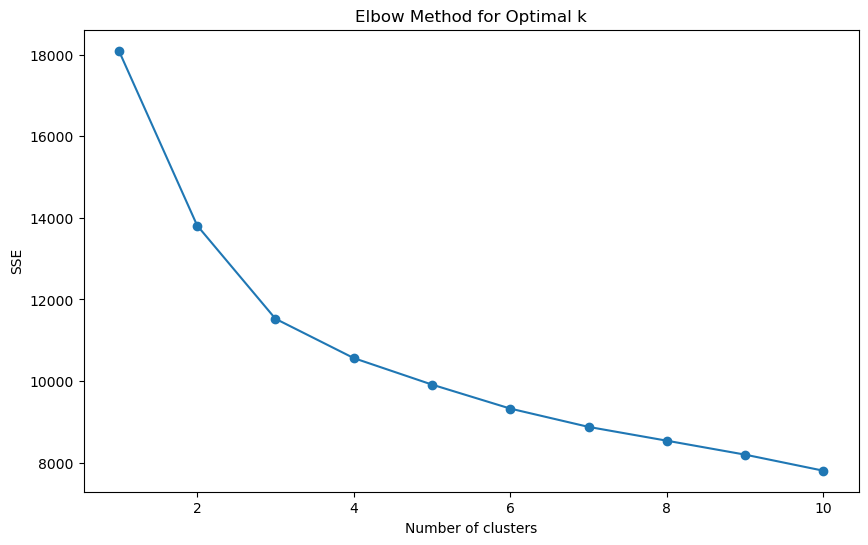

In [48]:
# Elbow method
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(range(1, 11), sse, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()

#### b. Use appropriate clustering algorithms

In [49]:
numeric_cols = [
    'acousticness', 'danceability', 'energy', 'instrumentalness', 
    'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 
    'popularity', 'duration_ms'
]
df_numeric = songs_cohort_df[numeric_cols]

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)
df_scaled

array([[ 0.85755561, -1.03548347,  0.97594713, ..., -1.19833618,
         1.17776377,  0.05469019],
       [ 0.76355292, -0.61140044,  0.99892171, ..., -1.22017326,
         1.17776377,  0.17354539],
       [ 1.43947699, -0.7315573 ,  1.09082001, ..., -1.94516418,
         1.00363094,  0.68195577],
       ...,
       [ 0.5621186 ,  2.244092  , -0.12108881, ...,  1.05961746,
         0.82949812, -0.86279299],
       [-0.12723443,  1.60796745, -1.43063956, ..., -0.26370934,
         0.56829888, -1.51020695],
       [ 0.61583442,  1.79880481,  0.79789418, ...,  1.6448511 ,
         1.26483018, -0.70681859]], shape=(1508, 11))

In [50]:
kmeans = KMeans(n_clusters=3, random_state=42)
songs_cohort_df['cluster'] = kmeans.fit_predict(df_scaled)
songs_cohort_df

,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,...,loudness,speechiness,tempo,valence,popularity,duration_ms,release_year,PC1,PC2,cluster
1,Street Fighting Man - Live,Licked Live In Nyc,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.820518,-1.007963,0.960062,0.249238,...,0.724545,0.123753,0.183852,-1.142678,1.063495,-0.042138,2022,2.168395,-1.055410,2
2,Start Me Up - Live,Licked Live In Nyc,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.728140,-0.584626,0.982305,0.853953,...,0.680109,0.881280,0.136323,-1.164306,1.063495,0.050079,2022,2.452620,-0.853685,2
3,If You Can't Rock Me - Live,Licked Live In Nyc,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,1.392383,-0.704571,1.071278,-0.594080,...,0.479980,2.392459,0.236514,-1.882359,0.902504,0.444539,2022,3.347635,-2.529040,2
4,Don’t Stop - Live,Licked Live In Nyc,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.657756,-1.170242,0.982305,-0.392050,...,0.625984,0.455050,0.152303,-1.627147,0.902504,0.437392,2022,2.630886,-1.764247,2
5,Monkey Man - Live,Licked Live In Nyc,2022-06-10,6,3ixZ1NQk5sqvBZgWeIdiqr,spotify:track:3ixZ1NQk5sqvBZgWeIdiqr,0.107886,-0.909184,0.910014,-0.141836,...,0.478644,0.425989,-0.836768,-1.977522,0.822008,-0.124132,2022,2.068548,-1.736924,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,Carol,The Rolling Stones,1964-04-16,8,08l7M5UpRnffGl0FyuRiQZ,spotify:track:08l7M5UpRnffGl0FyuRiQZ,-0.411192,-0.020176,0.776555,-0.572125,...,-0.749192,-0.515591,1.753944,1.664646,1.465975,-0.957125,1964,-0.418587,1.892700,0
1606,Tell Me,The Rolling Stones,1964-04-16,9,3JZllQBsTM6WwoJdzFDLhx,spotify:track:3JZllQBsTM6WwoJdzFDLhx,-0.848449,0.283215,-0.480188,-0.594461,...,-0.820356,0.286496,-0.139166,-0.588999,1.224487,-0.115148,1964,-0.202192,-0.826389,1
1607,Can I Get A Witness,The Rolling Stones,1964-04-16,10,0t2qvfSBQ3Y08lzRRoVTdb,spotify:track:0t2qvfSBQ3Y08lzRRoVTdb,0.530186,2.265844,-0.102053,-0.594467,...,-0.330558,0.048195,-0.993931,1.093665,0.741512,-0.753985,1964,-2.448151,1.006882,0
1608,You Can Make It If You Try,The Rolling Stones,1964-04-16,11,5ivIs5vwSj0RChOIvlY3On,spotify:track:5ivIs5vwSj0RChOIvlY3On,-0.147254,1.630838,-1.369917,-0.594213,...,-0.867131,-0.141672,-0.802344,-0.216997,0.500024,-1.256295,1964,-2.444479,-0.796502,1


#### c. Define each cluster based on the features

In [51]:
cluster_summary = songs_cohort_df.groupby('cluster')[numeric_cols].mean()
cluster_summary

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
cluster,,,,,,,,,,,
0,-0.291367,0.572144,0.252495,0.304961,-0.504799,0.222570,-0.386350,-0.128698,0.861351,0.210863,-0.327301
1,0.658509,0.293250,-1.175302,-0.296077,-0.606540,-0.818434,-0.488755,-0.365010,-0.257212,-0.030203,-0.193955
2,-0.297948,-0.743437,0.733825,-0.069041,0.954956,0.543294,0.553829,0.383305,-0.540854,-0.260850,0.249459


In [52]:
most_common_album = songs_cohort_df.groupby('cluster')['album'].agg(lambda x: x.mode()[0])
cluster_summary['common_album'] = most_common_album
cluster_summary

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,common_album
cluster,,,,,,,,,,,,
0,-0.291367,0.572144,0.252495,0.304961,-0.504799,0.222570,-0.386350,-0.128698,0.861351,0.210863,-0.327301,Honk (Deluxe)
1,0.658509,0.293250,-1.175302,-0.296077,-0.606540,-0.818434,-0.488755,-0.365010,-0.257212,-0.030203,-0.193955,Aftermath (Uk Version)
2,-0.297948,-0.743437,0.733825,-0.069041,0.954956,0.543294,0.553829,0.383305,-0.540854,-0.260850,0.249459,Voodoo Lounge Uncut (Live)


### Cluster Analysis

#### Cluster 0
**Representative Album:** *Honk (Deluxe)*

**Characteristics:**
- Low acousticness
- High danceability
- Moderately high energy
- High instrumentalness
- Low liveness
- Slightly higher loudness
- Low speechiness
- Slightly slower tempo
- Very high valence (more positive/happy songs)
- Highest popularity
- Slightly shorter song duration

**Interpretation:**
This cluster represents energetic, upbeat, and highly danceable songs with positive moods. These tracks are commercially successful and appear to be polished studio recordings with broad audience appeal.

---

#### Cluster 1
**Representative Album:** *Aftermath (UK Version)*

**Characteristics:**
- Highest acousticness
- Moderate danceability
- Lowest energy
- Low instrumentalness
- Low liveness
- Lower loudness
- Low speechiness
- Slower tempo
- Slightly negative valence
- Moderate popularity
- Slightly shorter duration

**Interpretation:**
This cluster contains softer, acoustic-oriented songs with lower energy and quieter production. These tracks are suitable for relaxed listening and exhibit moderate commercial popularity.

---

#### Cluster 2
**Representative Album:** *Voodoo Lounge Uncut (Live)*

**Characteristics:**
- Low acousticness
- Lowest danceability
- Highest energy
- Moderate instrumentalness
- Highest liveness
- Highest loudness
- Highest speechiness
- Fastest tempo
- Lowest valence (more intense or darker mood)
- Lowest popularity
- Longest song duration

**Interpretation:**
This cluster consists of energetic, live-performance-oriented tracks with high tempo and loudness. Despite their intensity, they are less danceable and have lower popularity, suggesting they cater to a more niche audience.

---

### Overall Insights

- **Cluster 0** represents **commercially successful, upbeat, danceable songs** with the highest positive mood and popularity.
- **Cluster 1** groups **acoustic, mellow, and low-energy tracks**, making them suitable for calm and relaxed listening.
- **Cluster 2** consists of **high-energy live performances** characterized by loudness, fast tempo, and strong stage presence, but with lower mainstream popularity.

The clustering effectively separates songs into three distinct musical styles based on their audio characteristics, demonstrating that features such as **acousticness, danceability, energy, tempo, valence, and liveness** are key factors in distinguishing different types of songs.